<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/Copy_of_Following_of_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

For this second step of the project I have chosen ["Time Series Air Quality Data of India (2010-2023)"](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption?select=powerconsumption.csv). The goal of the usage of this new dataset is to make models that can accurately predict the power consumption of the zones.

###**Imports**

In [ ]:
import os
import datetime
import kagglehub
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from zipfile import ZipFile

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

Import path and set df

In [ ]:
import os
# Download latest version
path = kagglehub.dataset_download("fedesoriano/electric-power-consumption")

print("Path to dataset files:", path)
df=pd.read_csv(os.path.join(path,'powerconsumption.csv'))
date_time = df.pop('Datetime')


Using Colab cache for faster access to the 'electric-power-consumption' dataset.
Path to dataset files: /kaggle/input/electric-power-consumption


Show top 5

In [ ]:
df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
print(df.describe())
print(df.info())

        Temperature      Humidity     WindSpeed  GeneralDiffuseFlows  \
count  52416.000000  52416.000000  52416.000000         52416.000000   
mean      18.810024     68.259518      1.959489           182.696614   
std        5.815476     15.551177      2.348862           264.400960   
min        3.247000     11.340000      0.050000             0.004000   
25%       14.410000     58.310000      0.078000             0.062000   
50%       18.780000     69.860000      0.086000             5.035500   
75%       22.890000     81.400000      4.915000           319.600000   
max       40.010000     94.800000      6.483000          1163.000000   

       DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
count  52416.000000            52416.000000            52416.000000   
mean      75.028022            32344.970564            21042.509082   
std      124.210949             7130.562564             5201.465892   
min        0.011000            13895.696200             8560.081466

I am lucky enough to not have any NANs or null here. However to note for Temperature and windspeed I am not given a metric. This won't impact largely the calculations. I will not need to convert any circuler data such as windspeed as well because it doesn't seem to be in degrees as seen in .describe().

Show the change of T, p, and rho over time

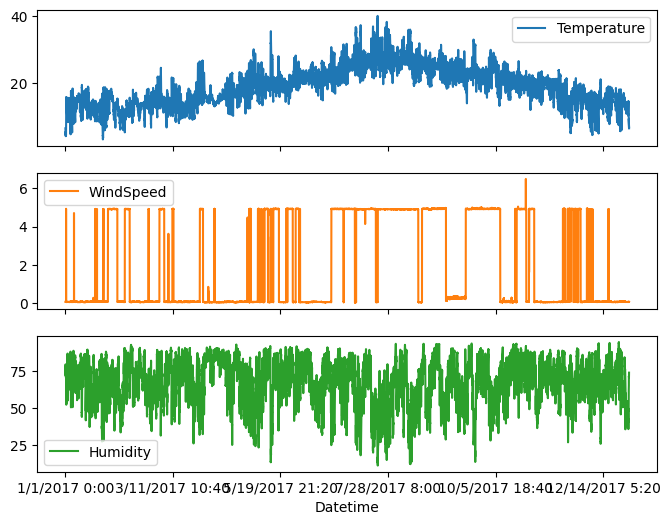

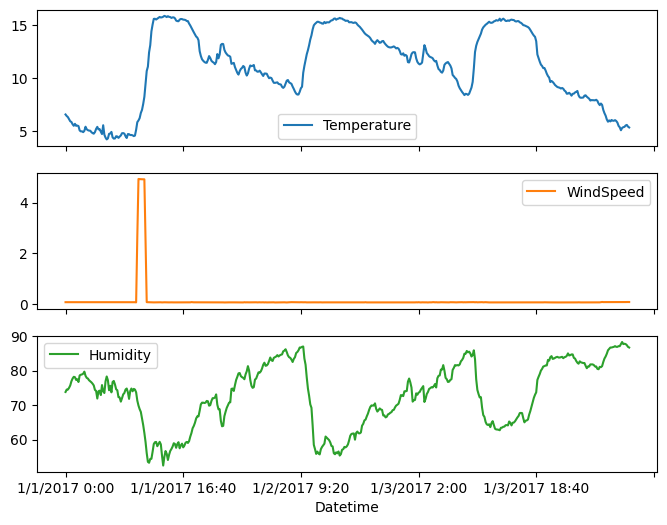

In [ ]:
plot_cols = ['Temperature', 'WindSpeed', 'Humidity']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True)

Split the data but no shuffling to maintain some order as this is time series data these patterns hold information

In [ ]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

data normilization through simple averages interesting to think about how only training data is used for this and how moving averages could be more honest

In [ ]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

view distribution through violin plots. The medians are all in similiar ranges but there are many with long tails but some with no tails through each feature

/tmp/ipykernel_3071/3214313372.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


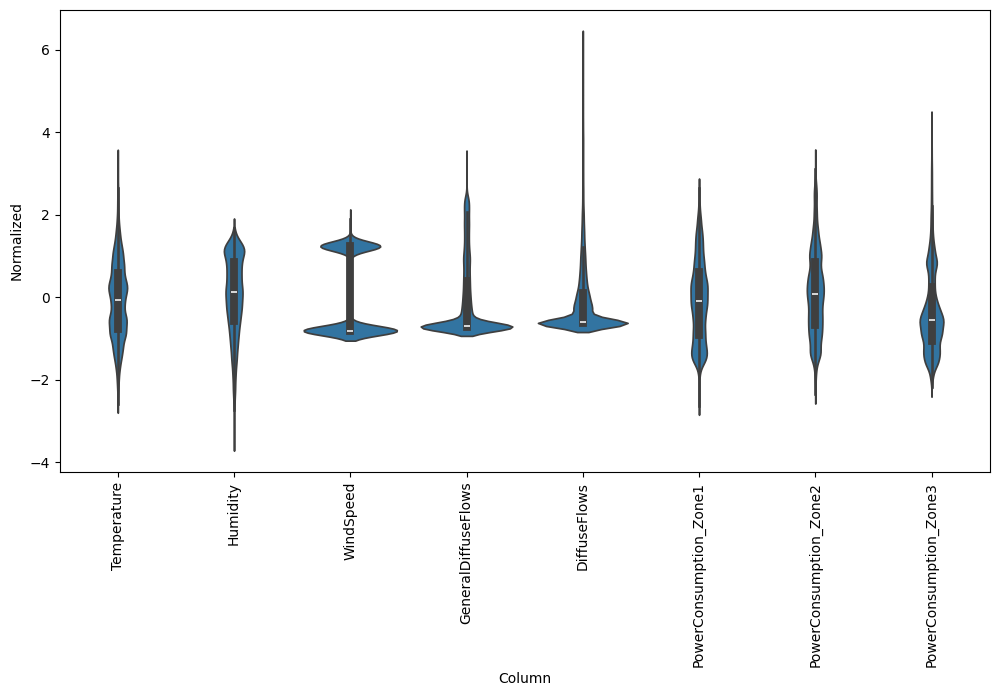

In [ ]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

data windowing here is implemented with hours and you can set the input of hours and how far you want to predict with what features

In [ ]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Determine input columns: Exclude any PowerConsumption_Zone columns
    # from inputs, as per user's request, unless they are explicitly part of label_columns.
    # This ensures that 'PowerConsumption_ZoneX' columns are *only* considered as labels.
    self.input_columns = [col for col in train_df.columns if not col.startswith('PowerConsumption_Zone')]
    self.input_column_indices = {name: self.column_indices[name] for name in self.input_columns}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}',
        f'Input column name(s): {self.input_columns}'])


making 2 windows with window size, input, labels, and label columns

In [ ]:
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['PowerConsumption_Zone1'])
print(w1)

w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['PowerConsumption_Zone1'])
print(w2)

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['PowerConsumption_Zone1']
Input column name(s): ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']
Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['PowerConsumption_Zone1']
Input column name(s): ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']


Split into two windows of one label to be predicted and the input information

In [ ]:
def split_window(self, features):
  # Get inputs from the feature set, selecting only the input_columns
  input_features_tensor = tf.stack(
      [features[:, :, self.column_indices[name]] for name in self.input_columns],
      axis=-1
  )
  inputs = input_features_tensor[:, self.input_slice, :]

  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, len(self.input_columns)])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

Test of split

In [ ]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 8)
Inputs shape: (3, 6, 5)
Labels shape: (3, 1, 1)


visualization of the split windows

In [ ]:
w2.example = example_inputs, example_labels

def plot(self, model=None, plot_col='PowerConsumption_Zone1', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))

  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')

    # Only plot inputs if the plot_col is one of the input features
    if plot_col in self.input_columns:
      input_plot_idx = self.input_column_indices[plot_col]
      plt.plot(self.input_indices, inputs[n, :, input_plot_idx],
               label='Inputs', marker='.', zorder=-10)

    label_plot_idx = None
    if self.label_columns and plot_col in self.label_columns:
      label_plot_idx = self.label_columns_indices[plot_col]

    if label_plot_idx is not None:
      plt.scatter(self.label_indices, labels[n, :, label_plot_idx],
                  edgecolors='k', label='Labels', c='#2ca02c', s=64)
      if model is not None:
        predictions = model(inputs)
        # Ensure model's output dimension matches what's being indexed
        if predictions.shape[-1] > label_plot_idx:
          plt.scatter(self.label_indices, predictions[n, :, label_plot_idx],
                      marker='X', edgecolors='k', label='Predictions',
                      c='#ff7f0e', s=64)
        else:
          print(f"Warning: Model predictions for '{plot_col}' not available (output dimension mismatch).")

    # If plot_col is neither an input column nor a label column, print a warning.
    if plot_col not in self.input_columns and (not self.label_columns or plot_col not in self.label_columns):
        print(f"Warning: '{plot_col}' is neither an input nor a label column in this window. Skipping plot for this column.")

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

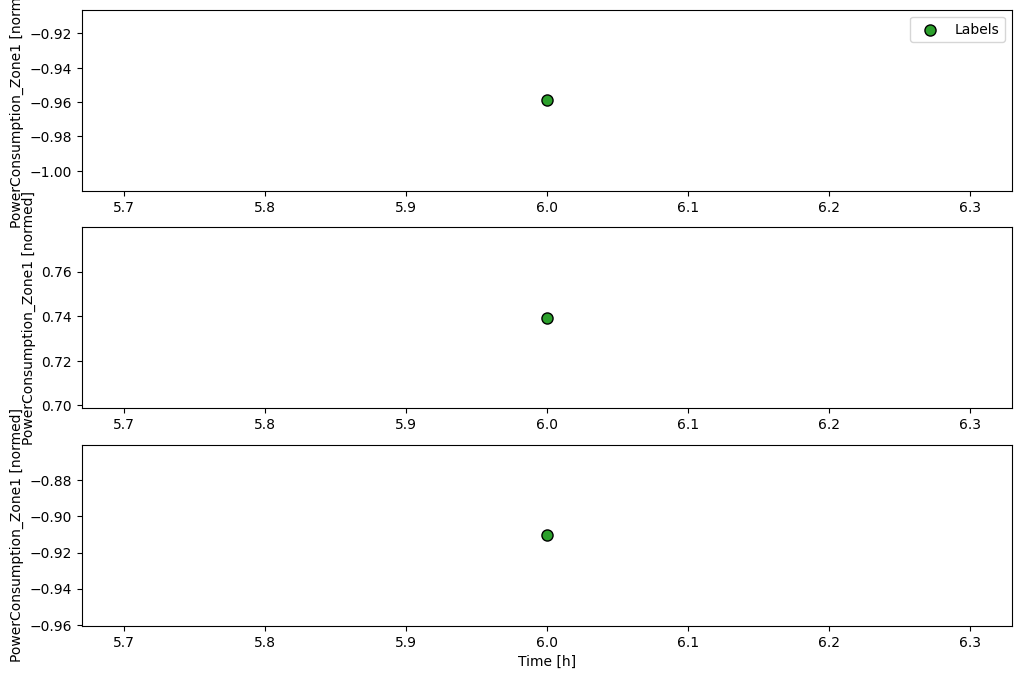

In [ ]:
w2.plot(plot_col='PowerConsumption_Zone1')

/tmp/ipykernel_3071/2173480714.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


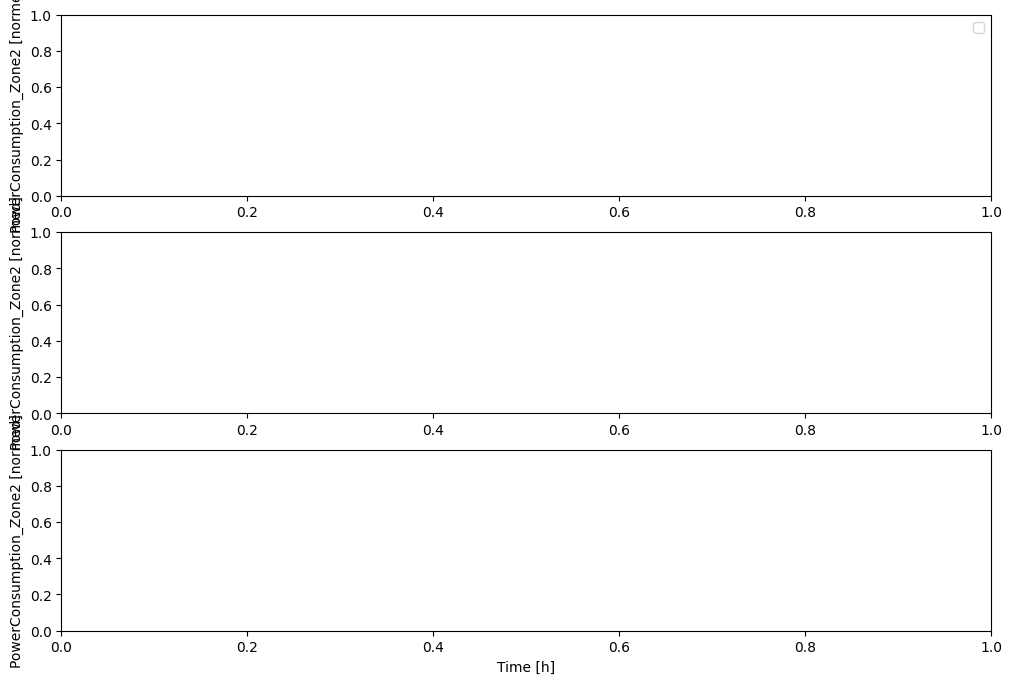

In [ ]:
w2.plot(plot_col='PowerConsumption_Zone2')

turning dataframe into tf dataset which is better for model ingestion and batching

In [ ]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

accessor funcs

In [ ]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

Show dataset specifications

In [ ]:
# Each element is an (inputs, label) pair.
w2.train.element_spec

(TensorSpec(shape=(None, 6, 5), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

show the batches created by the dataset

In [ ]:
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 5)
Labels shape (batch, time, features): (32, 1, 1)


Making a model that predicts one hour on a single feature

In [ ]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['PowerConsumption_Zone1'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['PowerConsumption_Zone1']
Input column name(s): ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']

iterate the model over the batches

In [ ]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 1, 5)
Labels shape (batch, time, features): (32, 1, 1)


Starting with predicting no chnage as a baseline performance of the single output model

In [ ]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

In [ ]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

baseline = Baseline(label_index=column_indices['PowerConsumption_Zone1'])

baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

ValueError: Exception encountered when calling Baseline.call().

[1mslice index 5 of dimension 2 out of bounds. for '{{node baseline_5_1/strided_slice}} = StridedSlice[Index=DT_INT32, T=DT_FLOAT, begin_mask=3, ellipsis_mask=0, end_mask=3, new_axis_mask=0, shrink_axis_mask=4](data, baseline_5_1/strided_slice/stack, baseline_5_1/strided_slice/stack_1, baseline_5_1/strided_slice/stack_2)' with input shapes: [?,1,5], [3], [3], [3] and with computed input tensors: input[1] = <0 0 5>, input[2] = <0 0 6>, input[3] = <1 1 1>.[0m

Arguments received by Baseline.call():
  • inputs=tf.Tensor(shape=(None, 1, 5), dtype=float32)

Each batch through time is indepedent from each other. so no interaction from the previous to impact the current prediction being made

In [ ]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'])

wide_window

show the shape and the plot

In [ ]:
class ZeroBaseline(tf.keras.Model):
  def __init__(self, output_steps, num_labels):
    super().__init__()
    self.output_steps = output_steps
    self.num_labels = num_labels

  def call(self, inputs):
    batch_size = tf.shape(inputs)[0]
    # Output shape should be (batch_size, output_steps, num_labels)
    return tf.zeros((batch_size, self.output_steps, self.num_labels))

# Instantiate the ZeroBaseline for wide_window
wide_window_zero_baseline = ZeroBaseline(
    output_steps=wide_window.label_width,
    num_labels=len(wide_window.label_columns)
)

print('Input shape:', wide_window.example[0].shape)
# Use the new zero baseline model
print('Output shape:', wide_window_zero_baseline(wide_window.example[0]).shape)

In [ ]:
wide_window.plot(wide_window_zero_baseline)

Making and training linear model with no transformation for activation making it just linear transformations

In [ ]:
linear = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1)
])

print('Input shape:', single_step_window.example[0].shape)
print('Output shape:', linear(single_step_window.example[0]).shape)

In [ ]:
MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

Eval

In [ ]:
history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = linear.evaluate(single_step_window.val, return_dict=True)
performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0, return_dict=True)

wide window visualizations

In [ ]:
wide_window.plot(wide_window_zero_baseline)

showing the weights of each layers weight
Random initialization could run the risk of not having a weight on certain features

In [ ]:
plt.bar(x = range(len(single_step_window.input_columns)),
        height=linear.layers[0].kernel[:,0].numpy())
axis = plt.gca()
axis.set_xticks(range(len(single_step_window.input_columns)))
_ = axis.set_xticklabels(single_step_window.input_columns, rotation=90)

print()

In [ ]:
print(single_step_window.input_columns)

Multi-layer version

In [ ]:
dense = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = dense.evaluate(single_step_window.val, return_dict=True)
performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

Creating new window and plotting it

In [ ]:
CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    label_columns=['PowerConsumption_Zone1'])

conv_window

In [ ]:
conv_window.plot()
plt.suptitle("Given 3 hours of inputs, predict 1 hour into the future.")

Train, fit, and plot model

In [ ]:
multi_step_dense = tf.keras.Sequential([
    # Shape: (time, features) => (time*features)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf.keras.layers.Reshape([1, -1]),
])

In [ ]:
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

In [ ]:
history = compile_and_fit(multi_step_dense, conv_window)

IPython.display.clear_output()
val_performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

In [ ]:
conv_window.plot(multi_step_dense)

Set up CNN and show outputs to compare with multilayer

In [ ]:
conv_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32,
                           kernel_size=(CONV_WIDTH,),
                           activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
])

In [ ]:
print("Conv model on `conv_window`")
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', conv_model(conv_window.example[0]).shape)

In [ ]:
history = compile_and_fit(conv_model, conv_window)

IPython.display.clear_output()
val_performance['Conv'] = conv_model.evaluate(conv_window.val, return_dict=True)
performance['Conv'] = conv_model.evaluate(conv_window.test, verbose=0, return_dict=True)

Showing how CNN can use different shapes

In [ ]:
print("Wide window")
print('Input shape:', wide_window.example[0].shape)
print('Labels shape:', wide_window.example[1].shape)
print('Output shape:', conv_model(wide_window.example[0]).shape)

There is now a need to balance the output and input. This would need to be fixed for training or plotting

In [ ]:
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)
wide_conv_window = WindowGenerator(
    input_width=INPUT_WIDTH,
    label_width=LABEL_WIDTH,
    shift=1,
    label_columns=['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'])

wide_conv_window

Show changes

In [ ]:
print("Wide conv window")
print('Input shape:', wide_conv_window.example[0].shape)
print('Labels shape:', wide_conv_window.example[1].shape)
print('Output shape:', conv_model(wide_conv_window.example[0]).shape)

Plot this new model

In [ ]:
wide_conv_window.plot(conv_model)

Now testing performance with an RNN model. It uses an internal state to move through a series of internal outputs to give one final output steo by step. You can also have a version with multiple steps being done and visible which is good for stacking RNN layers or training multiple steps at once.

Creating model

In [ ]:
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

RNN is good because of this sequential ability but not good for large scale/long sequences because of memory and the gradients decaying as backpropagation extends.

Shape

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

fitting and plotting

In [ ]:
history = compile_and_fit(lstm_model, wide_window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

wide_window.plot(lstm_model)

Performance views

In [ ]:
cm = lstm_model.metrics[1]
cm.metrics

In [ ]:
val_performance

Plotting performance of validation vs test

In [ ]:
x = np.arange(len(performance))
width = 0.3
metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in val_performance.values()]
test_mae = [v[metric_name] for v in performance.values()]

plt.ylabel('mean_absolute_error [T (degC), normalized]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
_ = plt.legend()

General performance of all models

In [ ]:
for name, value in performance.items():
  print(f'{name:12s}: {value[metric_name]:0.4f}')

Now the tutorial moves on to multistep prediction models with a singleshot method

Setup window

In [ ]:
OUT_STEPS = 24
multi_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               label_columns=['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'])

multi_window.plot()
multi_window

Slight change on baseline to have multiple predictions then plot

In [ ]:
class MultiStepLastBaseline(tf.keras.Model):
  def __init__(self, label_columns, column_indices, **kwargs):
    super().__init__(**kwargs)
    self.label_columns = label_columns
    # The number of label columns to predict
    self.num_label_columns = len(label_columns)
    # self.column_indices is no longer directly used for slicing `inputs`
    # because inputs don't contain label columns.

  def call(self, inputs):
    # inputs.shape = (batch, input_steps, num_input_features)
    batch_size = tf.shape(inputs)[0]
    # This baseline will now predict zeros for all label columns for all OUT_STEPS.
    # This is because the original "last value" of label columns cannot be
    # directly extracted from the filtered `inputs` tensor.
    return tf.zeros((batch_size, OUT_STEPS, self.num_label_columns))

last_baseline = MultiStepLastBaseline(label_columns=multi_window.label_columns,
                                      column_indices=multi_window.column_indices)
last_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                      metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance = {}
multi_performance = {}

multi_val_performance['Last'] = last_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Last'] = last_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(last_baseline)

Now with lack of change on days assumption

In [ ]:
class RepeatBaseline(tf.keras.Model):
  def __init__(self, out_steps, label_columns, **kwargs):
    super().__init__(**kwargs)
    self.out_steps = out_steps
    self.num_label_columns = len(label_columns)

  def call(self, inputs):
    # The RepeatBaseline will now predict zeros for all label columns for all OUT_STEPS,
    # as its name 'Repeat' implies it should provide a constant output, and
    # the previous implementation of directly returning inputs caused a shape mismatch.
    batch_size = tf.shape(inputs)[0]
    return tf.zeros((batch_size, self.out_steps, self.num_label_columns))

repeat_baseline = RepeatBaseline(out_steps=OUT_STEPS, label_columns=multi_window.label_columns)
repeat_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                        metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance['Repeat'] = repeat_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Repeat'] = repeat_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(repeat_baseline)

A linear model will be tested but it is shown it can't get the full picture because it can't see nonlinear relationships/ Only at a low dimension due to it's simplicity

In [ ]:
multi_linear_model = tf.keras.Sequential([
    # Take the last time-step.
    # Shape [batch, time, features] => [batch, 1, features]
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    # Shape => [batch, 1, out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_linear_model, multi_window)

IPython.display.clear_output()
multi_val_performance['Linear'] = multi_linear_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Linear'] = multi_linear_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_linear_model)

More layers can give it more power(understanding) but it is stil limited by a single input to then predict multiple

In [ ]:
multi_dense_model = tf.keras.Sequential([
    # Take the last time step.
    # Shape [batch, time, features] => [batch, 1, features]
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    # Shape => [batch, 1, dense_units]
    tf.keras.layers.Dense(512, activation='relu'),
    # Shape => [batch, out_steps*len(label_columns)]
    tf.keras.layers.Dense(OUT_STEPS*len(multi_window.label_columns),
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, len(label_columns)]
    tf.keras.layers.Reshape([OUT_STEPS, len(multi_window.label_columns)])
])

history = compile_and_fit(multi_dense_model, multi_window)

IPython.display.clear_output()
multi_val_performance['Dense'] = multi_dense_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Dense'] = multi_dense_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_dense_model)

CNN

Wide window gives more context to patterns and change

In [ ]:
CONV_WIDTH = 3
multi_conv_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, CONV_WIDTH, features]
    tf.keras.layers.Lambda(lambda x: x[:, -CONV_WIDTH:, :]),
    # Shape => [batch, 1, conv_units]
    tf.keras.layers.Conv1D(256, activation='relu', kernel_size=(CONV_WIDTH)),
    # Shape => [batch, 1,  out_steps*len(multi_window.label_columns)]
    tf.keras.layers.Dense(OUT_STEPS*len(multi_window.label_columns),
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, len(multi_window.label_columns)]
    tf.keras.layers.Reshape([OUT_STEPS, len(multi_window.label_columns)])
])

history = compile_and_fit(multi_conv_model, multi_window)

IPython.display.clear_output()

multi_val_performance['Conv'] = multi_conv_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Conv'] = multi_conv_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_conv_model)

RNN

Can take a long history of inputs and find whats relevant before making the next 24 hours prediction

In [ ]:
multi_lstm_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, lstm_units].
    # Adding more `lstm_units` just overfits more quickly.
    tf.keras.layers.LSTM(32, return_sequences=False),
    # Shape => [batch, out_steps*features].
    tf.keras.layers.Dense(OUT_STEPS*len(multi_window.label_columns),
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features].
    tf.keras.layers.Reshape([OUT_STEPS, len(multi_window.label_columns)])
])

history = compile_and_fit(multi_lstm_model, multi_window)

IPython.display.clear_output()

multi_val_performance['LSTM'] = multi_lstm_model.evaluate(multi_window.val, return_dict=True)
multi_performance['LSTM'] = multi_lstm_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_lstm_model)

Autoregressive model

This model makes predictions step by step but there is interaction from previous inputs that are ingested to get the next output. You can have a varying length of returned outputs and many of the single shot models can be turned to autoregressive

In the tutorial this will be done with a RNN model with manual managment

In [ ]:
class FeedBack(tf.keras.Model):
  def __init__(self, units, out_steps, label_columns_count, num_total_features, all_column_indices, label_columns):
    super().__init__()
    self.out_steps = out_steps
    self.units = units
    self.lstm_cell = tf.keras.layers.LSTMCell(units)
    # Also wrap the LSTMCell in an RNN to simplify the `warmup` method.
    self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
    self.dense = tf.keras.layers.Dense(label_columns_count)
    self.num_total_features = num_total_features
    self.all_column_indices = all_column_indices
    self.label_columns = label_columns
    # Pre-calculate indices of label columns within the full DataFrame
    self.label_column_indices_in_full_df = [all_column_indices[name] for name in label_columns]

In [ ]:
feedback_model = FeedBack(units=32, out_steps=OUT_STEPS,
                          label_columns_count=len(multi_window.label_columns),
                          num_total_features=multi_window.train_df.shape[1],
                          all_column_indices=multi_window.column_indices,
                          label_columns=multi_window.label_columns)

Setting the warmup for the RNN's internal state through history

In [ ]:
def warmup(self, inputs):
  # inputs.shape => (batch, time, num_total_features)
  # Extract only the label columns from the input sequence for the LSTM.
  # This ensures the LSTM processes `label_columns_count` features from the start.
  warmup_inputs = tf.stack(
      [inputs[:, :, idx] for idx in self.label_column_indices_in_full_df],
      axis=-1
  )

  # x.shape => (batch, lstm_units)
  x, *state = self.lstm_rnn(warmup_inputs) # Now lstm_cell will infer input_dim as label_columns_count (3)

  # predictions.shape => (batch, label_columns_count)
  prediction = self.dense(x)
  return prediction, state

FeedBack.warmup = warmup

Show internal state and make the first prediction

In [ ]:
full_warmup_inputs = tf.concat([multi_window.example[0], multi_window.example[1]], axis=-1)
prediction, state = feedback_model.warmup(full_warmup_inputs)
print(prediction.shape)

now iterating the model input feeding and storing outputs into a python list

In [ ]:
def call(self, inputs, training=None):
  # Use a TensorArray to capture dynamically unrolled outputs.
  predictions = []
  # Initialize the LSTM state.
  prediction, state = self.warmup(inputs)

  # Insert the first prediction.
  predictions.append(prediction)

  # Run the rest of the prediction steps.
  for n in range(1, self.out_steps):
    # Use the last prediction as input. Its shape (batch, label_columns_count)
    # now matches what lstm_cell expects due to changes in warmup.
    x = prediction
    # Execute one lstm step.
    x, state = self.lstm_cell(x, states=state,
                              training=training)
    # Convert the lstm output to a prediction.
    prediction = self.dense(x)
    # Add the prediction to the output.
    predictions.append(prediction)

  # predictions.shape => (time, batch, features)
  predictions = tf.stack(predictions)
  # predictions.shape => (batch, time, features)
  predictions = tf.transpose(predictions, [1, 0, 2])
  return predictions

FeedBack.call = call

In [ ]:
full_input_for_feedback = tf.concat([multi_window.example[0], multi_window.example[1]], axis=-1)
print('Output shape (batch, time, features): ', feedback_model(full_input_for_feedback).shape)

Train and plot

In [ ]:
history = compile_and_fit(feedback_model, multi_window)

IPython.display.clear_output()

multi_val_performance['AR LSTM'] = feedback_model.evaluate(multi_window.val, return_dict=True)
multi_performance['AR LSTM'] = feedback_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(feedback_model)

Show performance on each feature

In [ ]:
x = np.arange(len(multi_performance))
width = 0.3

metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in multi_val_performance.values()]
test_mae = [v[metric_name] for v in multi_performance.values()]

plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=multi_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

Average for each model through time steps

In [ ]:
for name, value in multi_performance.items():
  print(f'{name:8s}: {value[metric_name]:0.4f}')